# Image Pre-processing with Presidio

In [36]:
import cv2
import tempfile
import pathlib
from pathlib import Path
from PIL import Image
from IPython.display import display

from presidio_image_redactor import (
    ImagePreprocessor,
    BilateralFilter,
    SegmentedAdaptiveThreshold,
    ImageRescaling,
    ContrastSegmentedImageEnhancer,
)

# ImagePreprocessor called in ImageAnalyzerEngine
DefaultImagePreProcessor = ImagePreprocessor()
BilateralPreProcessor = BilateralFilter()
SegmentedAdaptiveThresholdPreProcessor = SegmentedAdaptiveThreshold()
ImageRescalingPreProcessor = ImageRescaling()
ContrastSegmentedImageEnhancerPreProcessor = ContrastSegmentedImageEnhancer()

### DICOM Image Processing
* Dicom images need to be converted to PNG files for processing
* The DicomImageRedactorEngine has a method to do this

In [37]:
from presidio_image_redactor import DicomImageRedactorEngine

MyDicomRedactorEngine = DicomImageRedactorEngine()

# Load DICOM file
test_dicom_path = Path("/home/maxthorpe/Git/presidio-image-redactor/docs/notebooks/test_images/single_frame_US.dcm")

# Load image for processing
with tempfile.TemporaryDirectory() as tmpdirname:
    # Convert DICOM to PNG and add padding for OCR
    _, is_greyscale = MyDicomRedactorEngine._convert_dcm_to_png(
        test_dicom_path, output_dir=tmpdirname
    )

    # With file saved to temp directory, load image for pre-processing
    png_filepath = f"{tmpdirname}/{test_dicom_path.stem}.png"
    loaded_image = Image.open(png_filepath)
    image = MyDicomRedactorEngine._add_padding(
        loaded_image, is_greyscale, padding_width=25
    )

### Default Image Preprocessing Class 
1. Doesn't actually pre-process, just returns image as it was input
2. Has dicom to png conversion method which all other classes use


{}


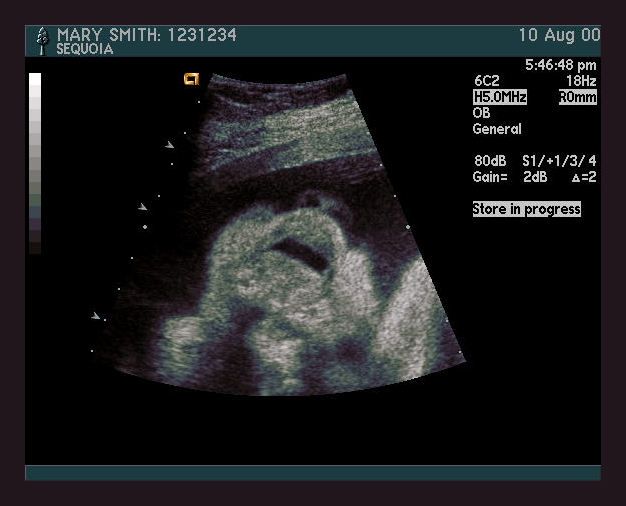

(506, 626)


In [38]:
# Pass our converted DICOM image to the preprocessor
(
    default_image,
    preprocessing_metadata,
) = DefaultImagePreProcessor.preprocess_image(image)

print(preprocessing_metadata)
display(default_image)

# Convert Image to pixel array to be used by remaining pre-processors
image = DefaultImagePreProcessor.convert_image_to_array(image)
print(image.shape)

### Bilateral Filter Image Preprocessing Class 

{'diameter': 3, 'sigma_color': 40, 'sigma_space': 40}


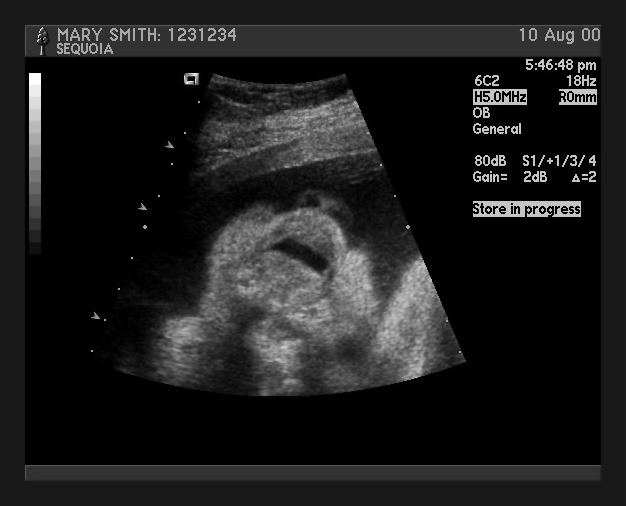

In [39]:
# Pass our converted DICOM image to the preprocessor
# BilateralPreProcessor.diameter = 3
# BilateralPreProcessor.sigma_color = 40
# BilateralPreProcessor.sigma_space = 40
(
    bilateral_filtered_image,
    preprocessing_metadata,
) = BilateralPreProcessor.preprocess_image(image)

print(preprocessing_metadata)
display(bilateral_filtered_image)

### Segmented Adaptive Threshold Filter Image Preprocessing Class 

{'C': 40, 'background_color': 0, 'contrast': 43.30613505351591}


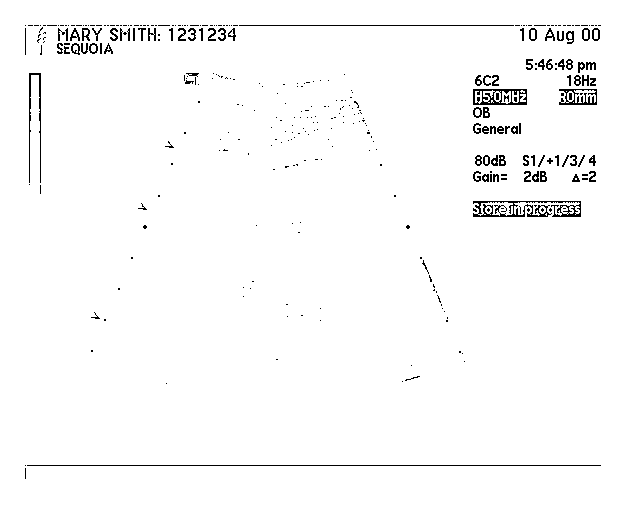

In [40]:
# Pass our converted DICOM image to the preprocessor
# SegmentedAdaptiveThresholdPreProcessor.block_size = 5
# SegmentedAdaptiveThresholdPreProcessor.contrast_threshold = 40
# SegmentedAdaptiveThresholdPreProcessor.c_low_contrast = 10
# SegmentedAdaptiveThresholdPreProcessor.c_high_contrast = 40
# SegmentedAdaptiveThresholdPreProcessor.bg_threshold = 122
(
    seg_adaptive_threshold_image,
    preprocessing_metadata,
) = SegmentedAdaptiveThresholdPreProcessor.preprocess_image(image)

print(preprocessing_metadata)
display(seg_adaptive_threshold_image)

### Rescaling Image Preprocessing Class 

{'scale_factor': 2}


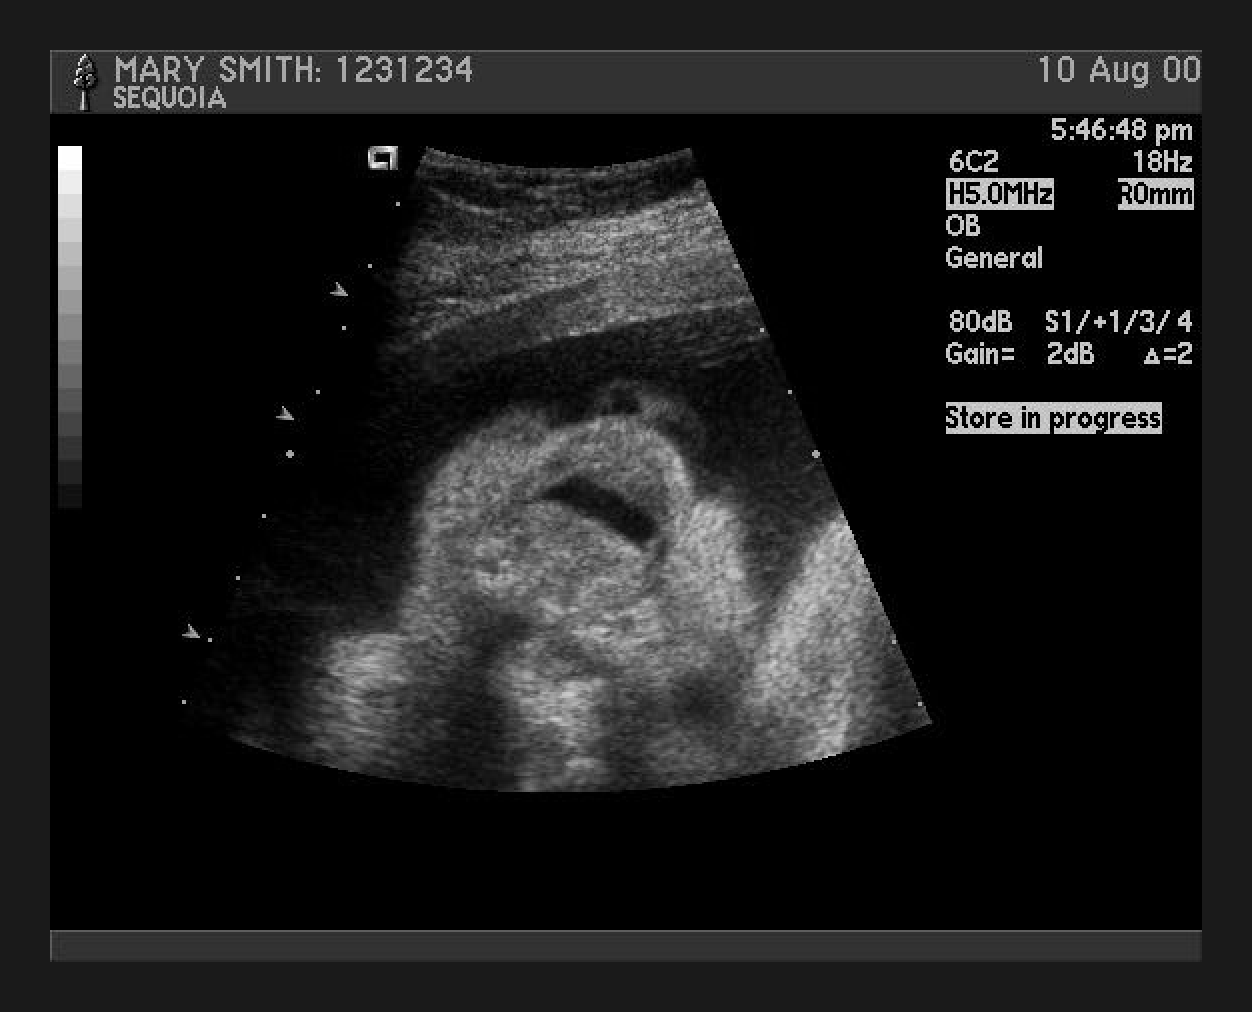

In [41]:
# Pass our converted DICOM image to the preprocessor
# ImageRescalingPreProcessor.small_size = 1048576
# ImageRescalingPreProcessor.large_size = 4000000
# ImageRescalingPreProcessor.factor = 2
# ImageRescalingPreProcessor.interpolation = cv2.INTER_AREA
(
    rescaled_image,
    preprocessing_metadata,
) = ImageRescalingPreProcessor.preprocess_image(image)

print(preprocessing_metadata)
display(rescaled_image)

### Contrast Segmented Image Preprocessing Class (all methods applied together)

{'scale_factor': 2}


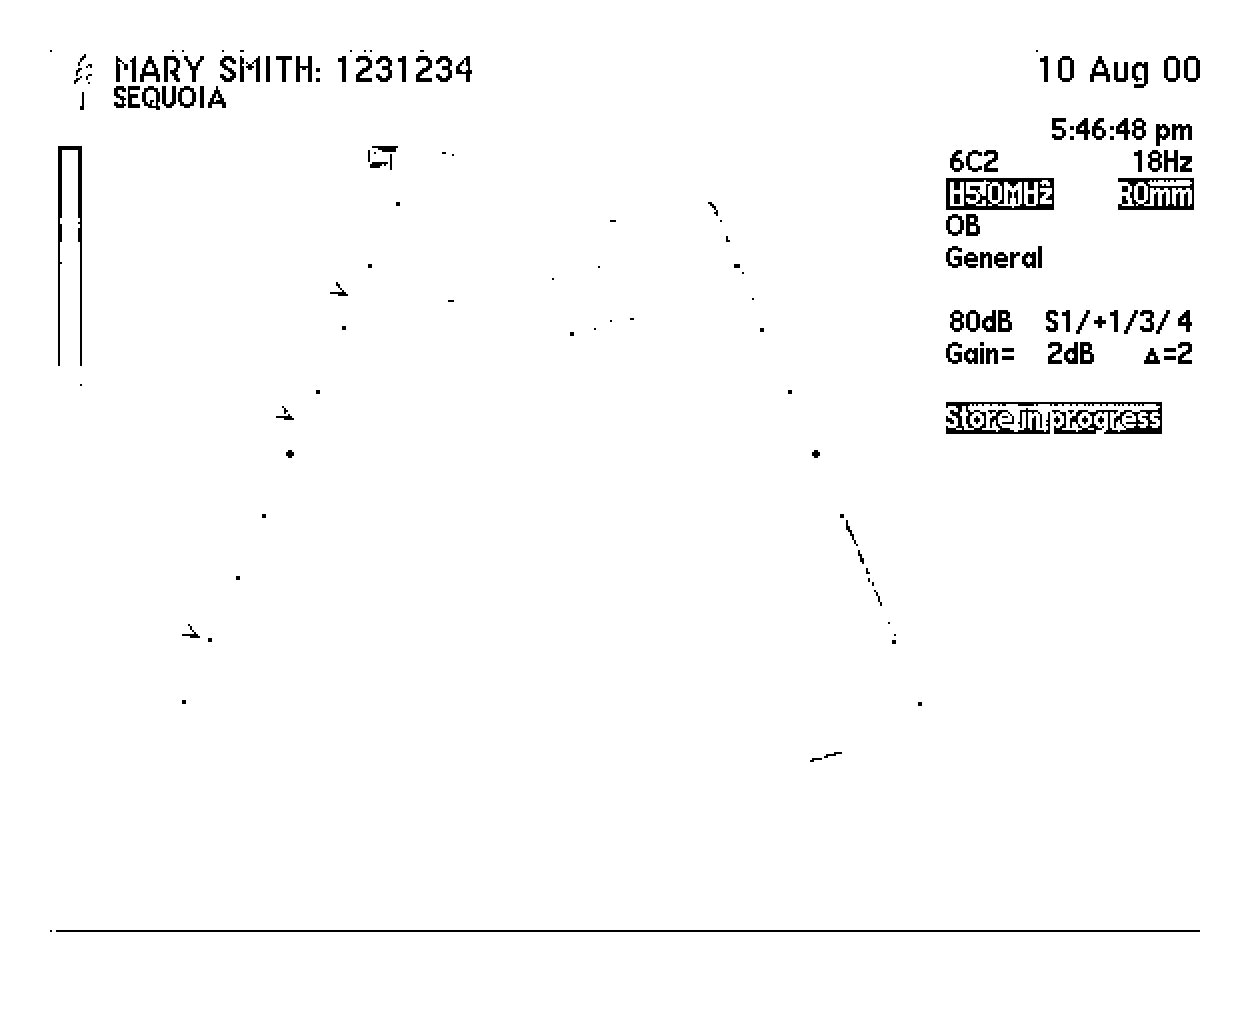

In [42]:
# Pass our converted DICOM image to the preprocessor
(
    contrast_seg_image,
    preprocessing_metadata,
) = ContrastSegmentedImageEnhancerPreProcessor.preprocess_image(image)

print(preprocessing_metadata)
display(contrast_seg_image)